# MNIST One-Class / One-vs-Rest Outlier Detection

**Goal:** treat one digit as **normal** and all others as **outliers**, then train a detector (typically on normal-only) and evaluate on a mixed test set.

**Conventions**
- `y = 0` → normal
- `y = 1` → outlier
- higher anomaly score → more anomalous

**Make it modifiable**
- Set `NORMAL_DIGITS = [0]` (or any digit list) to change what is "normal".


In [ ]:
!pip -q install -r ../requirements.txt

In [1]:
import sys
sys.path.append('..')
from common.utils import *

## Data

In [2]:
SEED = 42
import numpy as np
from sklearn.model_selection import train_test_split

import torch
from torchvision import datasets, transforms

# ----------------------------
# Config
# ----------------------------
DATA_DIR = "./data"
VAL_SIZE = 0.2

MAX_TRAIN_NORMAL = 20000   # speed cap; set None for full
MAX_VAL_TOTAL = 8000       # speed cap; set None for full
MAX_TEST_TOTAL = 10000     # speed cap; set None for full

rng = np.random.default_rng(SEED)

# ----------------------------
# Load MNIST once
# ----------------------------
tfm = transforms.ToTensor()
train_full = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=tfm)
test_full  = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=tfm)

def to_numpy(ds):
    X = ds.data.numpy().astype(np.float32) / 255.0  # [N,28,28]
    y = ds.targets.numpy().astype(int)
    return X, y

Xtr_all, ytr_all = to_numpy(train_full)
Xte_all, yte_all = to_numpy(test_full)

def build_splits(normal_digit: int):
    """
    Returns flattened arrays:
      X_train_flat: normals only (train)
      X_val_flat, y_val: mixed (0 normal, 1 outlier)
      X_test_flat, y_test: mixed (0 normal, 1 outlier)
    """
    NORMAL_DIGITS = [normal_digit]

    # --- normal-only pool from training set ---
    normal_mask = np.isin(ytr_all, NORMAL_DIGITS)
    X_normal = Xtr_all[normal_mask]

    # train/val split within normal pool
    X_train_n, X_val_n = train_test_split(
        X_normal, test_size=VAL_SIZE, random_state=SEED, shuffle=True
    )

    if MAX_TRAIN_NORMAL is not None:
        X_train_n = X_train_n[:MAX_TRAIN_NORMAL]
    if MAX_VAL_TOTAL is not None:
        X_val_n = X_val_n[:MAX_VAL_TOTAL]

    # --- validation outliers: balanced with normals ---
    out_mask = ~np.isin(ytr_all, NORMAL_DIGITS)
    X_out_pool = Xtr_all[out_mask]

    n_val_norm = len(X_val_n)
    n_val_out = min(len(X_out_pool), n_val_norm)

    out_idx = rng.permutation(len(X_out_pool))[:n_val_out]
    X_val_out = X_out_pool[out_idx]

    X_val = np.concatenate([X_val_n, X_val_out], axis=0)
    y_val = np.concatenate([
        np.zeros(len(X_val_n), dtype=int),
        np.ones(len(X_val_out), dtype=int)
    ], axis=0)

    # --- test: full MNIST test, labeled one-vs-rest ---
    X_test = Xte_all
    y_test = (~np.isin(yte_all, NORMAL_DIGITS)).astype(int)

    if MAX_TEST_TOTAL is not None:
        X_test = X_test[:MAX_TEST_TOTAL]
        y_test = y_test[:MAX_TEST_TOTAL]

    # flatten
    X_train_flat = X_train_n.reshape(len(X_train_n), -1)
    X_val_flat   = X_val.reshape(len(X_val), -1)
    X_test_flat  = X_test.reshape(len(X_test), -1)

    return X_train_flat, X_val_flat, y_val, X_test_flat, y_test


## Model: One-Class SVM (with PCA)

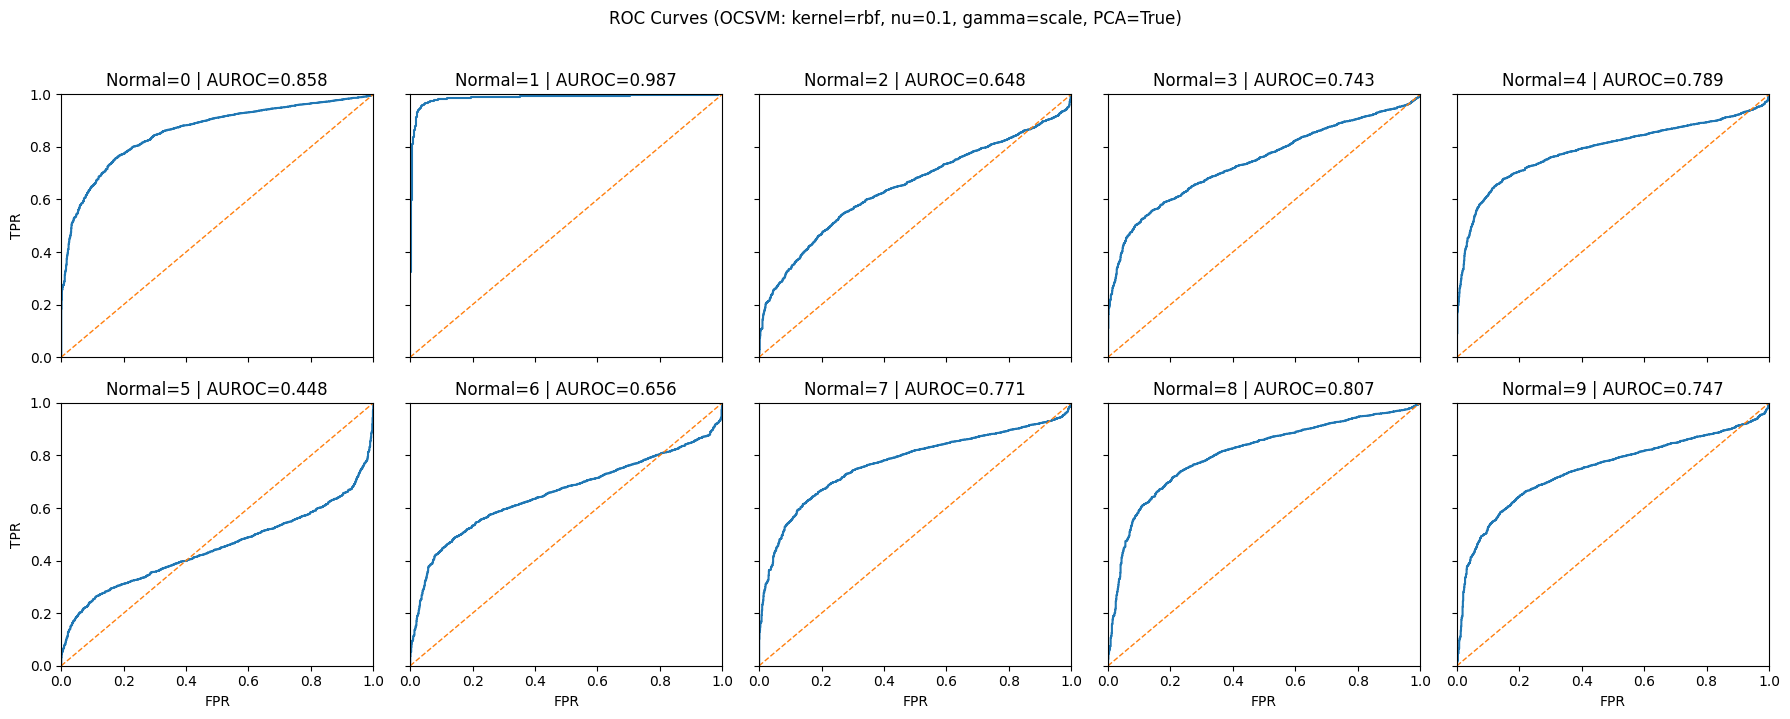

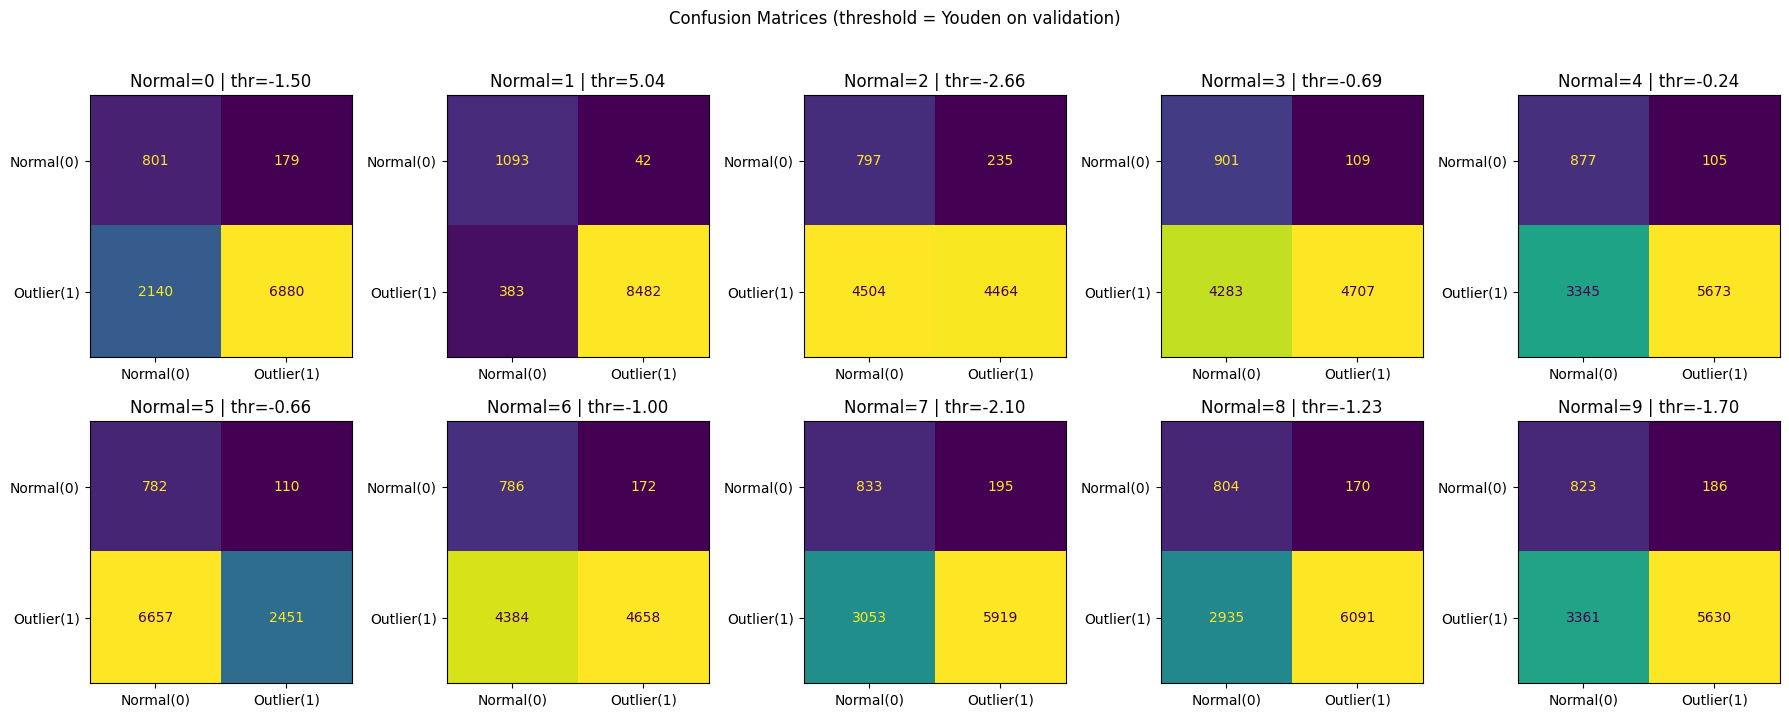

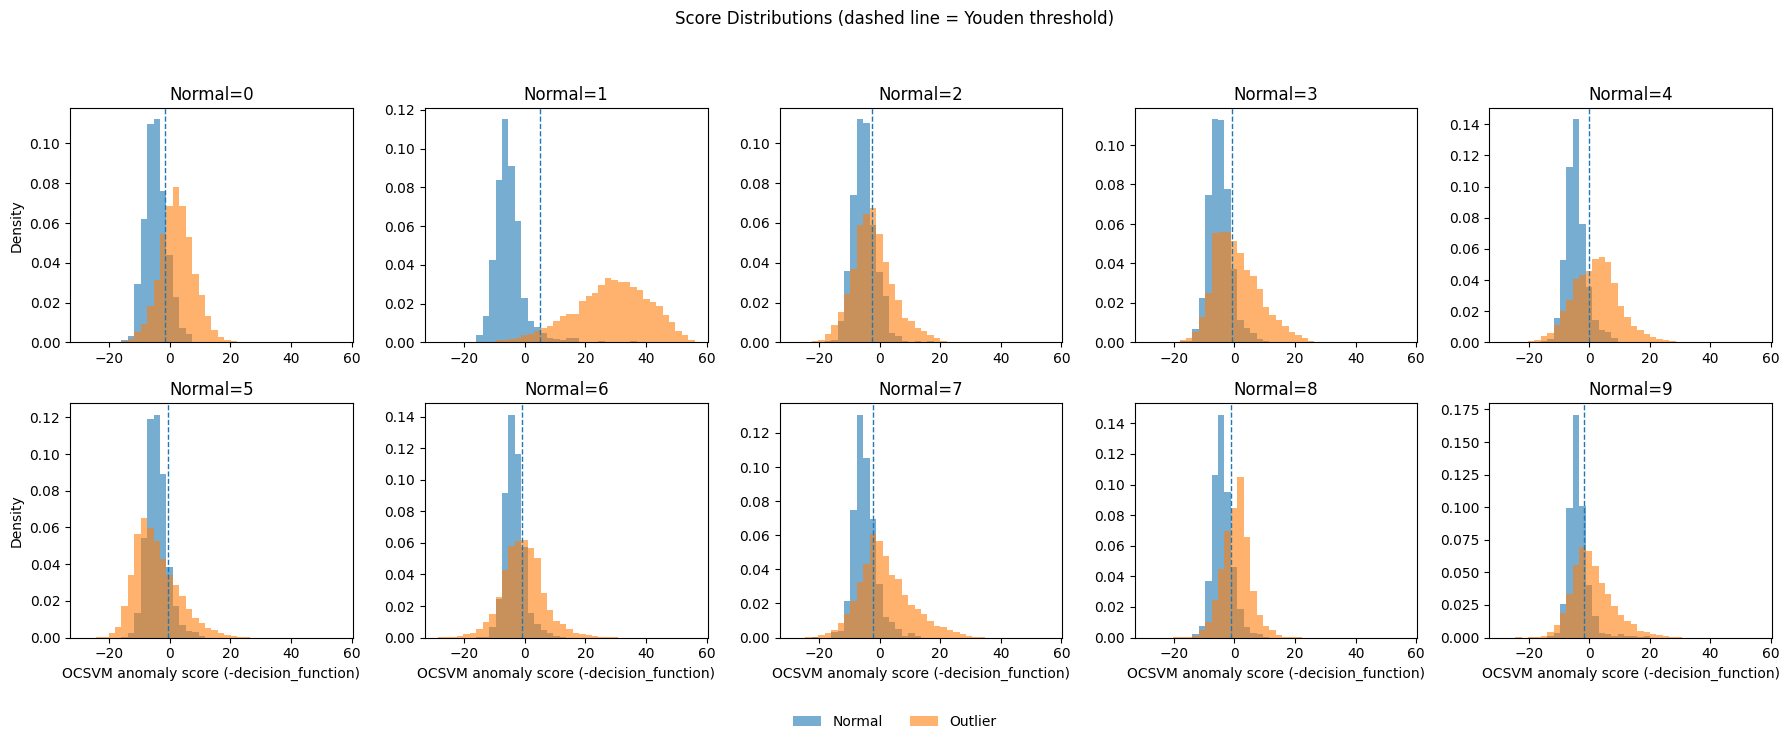

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# If your notebook already has choose_threshold_youden, keep using it.
# Otherwise, use this implementation:
def choose_threshold_youden(y_true, scores):
    fpr, tpr, thr = roc_curve(y_true, scores)
    j = tpr - fpr
    return thr[np.argmax(j)]

# ----------------------------
# OCSVM settings (adjust to your notebook defaults)
# ----------------------------
USE_PCA = True
PCA_DIM = 50

# Typical knobs
NU = 0.1
KERNEL = "rbf"
GAMMA = "scale"  # or float

def run_one(normal_digit: int):
    X_train_flat, X_val_flat, y_val, X_test_flat, y_test = build_splits(normal_digit)

    # PCA fit on normals only
    if USE_PCA:
        pca = PCA(n_components=PCA_DIM, random_state=SEED)
        X_train_z = pca.fit_transform(X_train_flat)
        X_val_z   = pca.transform(X_val_flat)
        X_test_z  = pca.transform(X_test_flat)
    else:
        X_train_z, X_val_z, X_test_z = X_train_flat, X_val_flat, X_test_flat

    # One-Class SVM fit on normal embeddings
    oc = OneClassSVM(kernel=KERNEL, nu=NU, gamma=GAMMA)
    oc.fit(X_train_z)

    # decision_function: higher usually means "more normal"
    # Convert to anomaly score: higher = more anomalous
    scores_val  = -oc.decision_function(X_val_z).ravel()
    scores_test = -oc.decision_function(X_test_z).ravel()

    # ROC / AUROC on test
    auroc = roc_auc_score(y_test, scores_test)
    fpr, tpr, _ = roc_curve(y_test, scores_test)

    # threshold from validation via Youden
    thr = choose_threshold_youden(y_val, scores_val)

    # confusion matrix on test
    y_hat = (scores_test >= thr).astype(int)
    cm = confusion_matrix(y_test, y_hat, labels=[0, 1])

    return fpr, tpr, auroc, cm, scores_test, y_test, thr

# ----------------------------
# Run for all digits
# ----------------------------
results = []
for d in range(10):
    results.append((d, *run_one(d)))

# ----------------------------
# 1) ROC curves / AUROC (2x5)
# ----------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
axes = axes.ravel()

for i, (d, fpr, tpr, auroc, cm, scores_test, y_test, thr) in enumerate(results):
    ax = axes[i]
    ax.plot(fpr, tpr)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(f"Normal={d} | AUROC={auroc:.3f}")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    if i % 5 == 0:
        ax.set_ylabel("TPR")
    if i >= 5:
        ax.set_xlabel("FPR")

fig.suptitle(f"ROC Curves (OCSVM: kernel={KERNEL}, nu={NU}, gamma={GAMMA}, PCA={USE_PCA})", y=1.02)
fig.tight_layout()

# ----------------------------
# 2) Confusion matrices (2x5)
# ----------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

for i, (d, fpr, tpr, auroc, cm, scores_test, y_test, thr) in enumerate(results):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal(0)", "Outlier(1)"])
    disp.plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"Normal={d} | thr={thr:.2f}")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Confusion Matrices (threshold = Youden on validation)", y=1.02)
fig.tight_layout()

# ----------------------------
# 3) Score distributions (2x5)
# ----------------------------
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

all_scores = np.concatenate([r[5] for r in results])  # scores_test across digits
bins = np.histogram_bin_edges(all_scores, bins=40)

for i, (d, fpr, tpr, auroc, cm, scores_test, y_test, thr) in enumerate(results):
    ax = axes[i]
    s_norm = scores_test[y_test == 0]
    s_out  = scores_test[y_test == 1]

    ax.hist(s_norm, bins=bins, alpha=0.6, density=True, label="Normal")
    ax.hist(s_out,  bins=bins, alpha=0.6, density=True, label="Outlier")
    ax.axvline(thr, linestyle="--", linewidth=1)

    ax.set_title(f"Normal={d}")
    if i % 5 == 0:
        ax.set_ylabel("Density")
    if i >= 5:
        ax.set_xlabel("OCSVM anomaly score (-decision_function)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

fig.suptitle("Score Distributions (dashed line = Youden threshold)", y=1.04)
fig.tight_layout(rect=[0, 0.06, 1, 1])
